In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df = pd.read_csv("../data/housing.csv")

## **Parte 1: Qualidade e estrutura dos dados**

In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 511 entries, 0 to 510
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     511 non-null    float64
 1   ZN       511 non-null    float64
 2   INDUS    511 non-null    float64
 3   CHAS     511 non-null    int64  
 4   NOX      511 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      511 non-null    float64
 7   DIS      511 non-null    float64
 8   RAD      511 non-null    int64  
 9   TAX      511 non-null    int64  
 10  PTRATIO  511 non-null    float64
 11  B        511 non-null    float64
 12  LSTAT    511 non-null    float64
 13  MEDV     511 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 56.0 KB


In [25]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,511.000000,511.000000,511.000000,511.000000,511.000000,506.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000,511.000000
mean,3.584139,11.252446,11.151096,0.068493,0.554757,6.287589,68.616243,3.783876,9.485323,407.440313,18.500000,356.600900,12.879550,22.682192
std,8.564433,23.234838,6.828175,0.252838,0.115310,0.703802,28.099130,2.098631,8.688469,167.903532,2.200348,90.882679,7.797416,9.484262
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082325,0.000000,5.190000,0.000000,0.449000,5.885500,45.050000,2.100350,4.000000,279.500000,17.400000,374.710000,7.065000,17.050000
50%,0.261690,0.000000,9.690000,0.000000,0.538000,6.209000,77.300000,3.152300,5.000000,330.000000,19.100000,391.340000,11.450000,21.200000
75%,3.621175,12.500000,18.100000,0.000000,0.624000,6.629750,94.050000,5.118000,24.000000,666.000000,20.200000,396.210000,17.105000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,23.000000,396.900000,76.000000,67.000000


In [ ]:
for i in df.columns:
    print(f"Valores únicos de {i}: {df[i].nunique()}")

Valores únicos de CRIM: 509
Valores únicos de ZN: 26
Valores únicos de INDUS: 79
Valores únicos de CHAS: 2
Valores únicos de NOX: 82
Valores únicos de RM: 444
Valores únicos de AGE: 357
Valores únicos de DIS: 416
Valores únicos de RAD: 9
Valores únicos de TAX: 67
Valores únicos de PTRATIO: 47
Valores únicos de B: 360
Valores únicos de LSTAT: 460
Valores únicos de MEDV: 231


In [ ]:
print((df["MEDV"] == 50.0).sum())
df["MEDV"].value_counts().sort_index(ascending=False).head(10)

16


MEDV
67.0     1
54.0     1
50.0    16
48.8     1
48.5     1
48.3     1
46.7     1
46.0     1
45.4     1
44.8     1
Name: count, dtype: int64

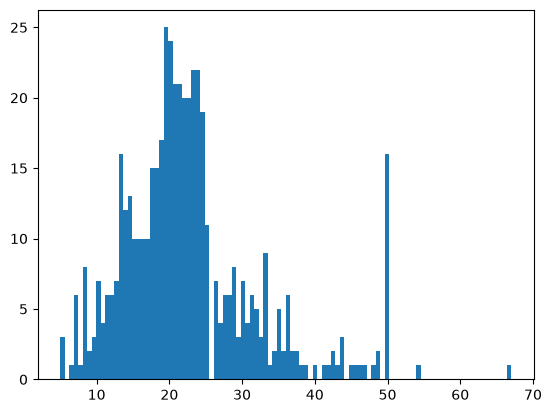

In [ ]:
plt.hist(df["MEDV"], bins=100)
plt.show()  

## **Parte 2: Análise univariada**

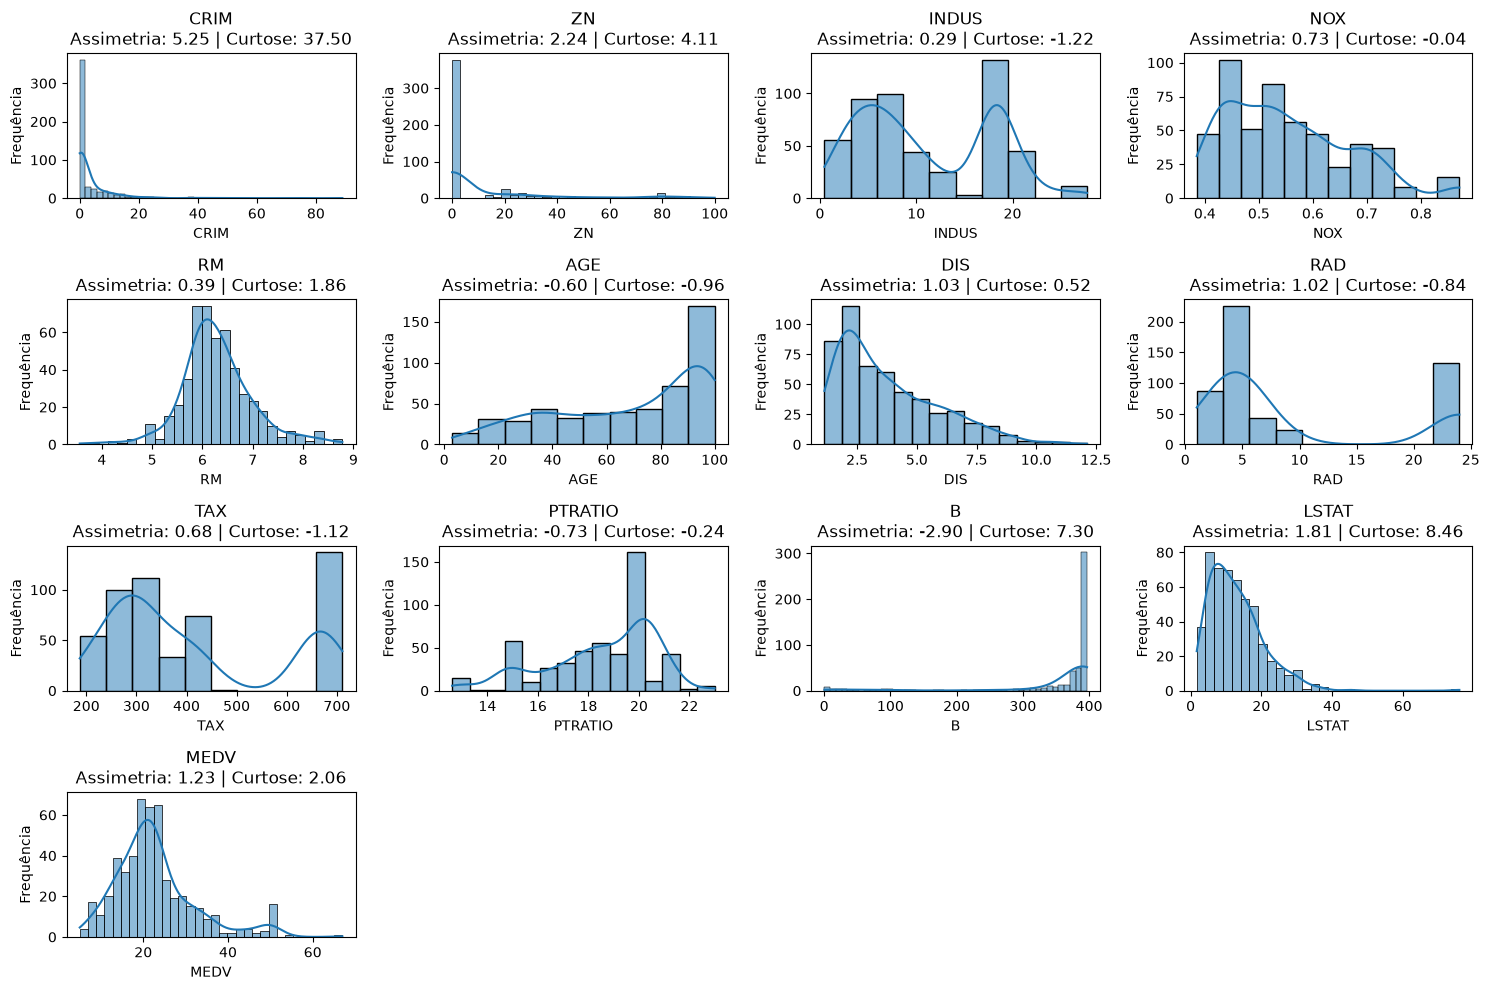

In [ ]:
variaveis = ['CRIM', 'ZN', 'INDUS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV']

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(15, 10)
)

axes = axes.ravel()

for ax, variavel in zip(axes.ravel(), variaveis):
    sns.histplot(
        data=df,
        x=variavel,
        ax=ax,
        kde=True
    )

    assimetria = df[variavel].skew()
    curtose = df[variavel].kurt()

    ax.set_title(
        f"{variavel}\n"
        f"Assimetria: {assimetria:.2f} | Curtose: {curtose:.2f}"
    )

    ax.set_ylabel("Frequência")

# Remove os subplots vazios
for ax in axes[len(variaveis):]:
    ax.remove()

plt.tight_layout()
plt.show()

In [ ]:
df["logCRIM"] = np.log1p(df["CRIM"])
df["logZN"] = np.log1p(df["ZN"])
df["logDIS"] = np.log(df["DIS"])
df["logLSTAT"] = np.log(df["LSTAT"])
df["logMEDV"] = np.log(df["MEDV"])

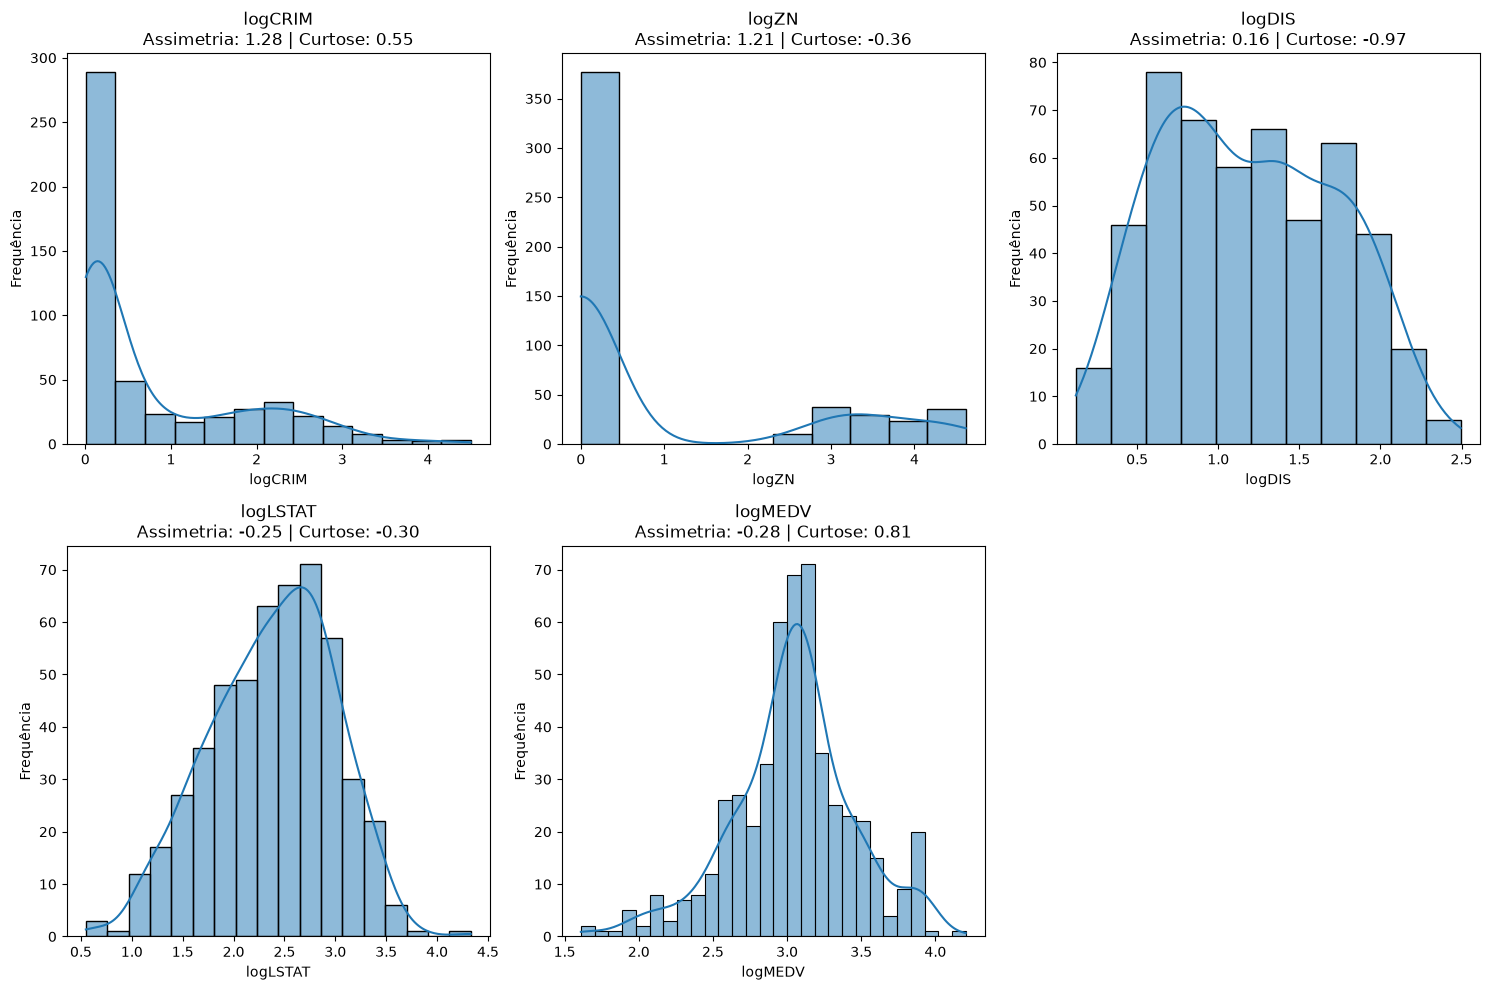

In [32]:
novas_variaveis = ["logCRIM", "logZN", "logDIS", "logLSTAT", "logMEDV"]

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(15, 10)
)

axes = axes.ravel()

for ax, variavel in zip(axes.ravel(), novas_variaveis):
    sns.histplot(
        data=df,
        x=variavel,
        ax=ax,
        kde=True
    )

    assimetria = df[variavel].skew()
    curtose = df[variavel].kurt()

    ax.set_title(
        f"{variavel}\n"
        f"Assimetria: {assimetria:.2f} | Curtose: {curtose:.2f}"
    )

    ax.set_ylabel("Frequência")

# Remove os subplots vazios
for ax in axes[len(novas_variaveis):]:
    ax.remove()

plt.tight_layout()
plt.show()